# PROJECT-1

# NEWYORK CITY TAXI FARE PREDICTION

The **New York City Taxi Fare Prediction dataset**, sourced from Kaggle includes data from six years ago, contains comprehensive records of taxi rides in New York City. It is designed to facilitate the development and testing of machine learning models aimed at predicting taxi fares based on various factors

Dataset link: https://www.kaggle.com/datasets/dansbecker/new-york-city-taxi-fare-prediction/data

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

We import pandas for tabular data manipulation, seaborn for advanced visualizations, matplotlib.pyplot for customizing plots, and numpy for numerical operations like array handling and computations.

# Dataset Column Overview

1. **trip_duration**: The total time, usually measured in seconds or minutes, that the trip took from start to finish.

2. **distance_traveled**: The total distance covered during the trip, typically measured in miles or kilometers.


3. **num_of_passengers**: The number of passengers in the vehicle during the trip.

4. **fare**: The base fare for the trip, which is the starting charge before any additional fees, tips, or surcharges.

5. **tip**: The amount of tip given by the passenger to the driver, usually a percentage of the fare.

6. **miscellaneous_fees**: Any additional fees that are not part of the base fare, such as tolls or service charges.

7. **total_fare**: The final amount charged to the passenger, which is the sum of the fare, tip, and any miscellaneous fees.

8. **surge_applied**: Indicates whether a surge pricing factor was applied during the trip (e.g., during high demand), usually represented as a boolean value or a numeric multiplier.

# Classification Algorithms Overview

 The classification algorithms  used: 
>**Logistic Regression**,

>**Decision Tree Classifier (DTC)**,

>**K-Nearest Neighbors (KNN)**,

>**Random Forest**,

>**Support Vector Classifier (SVC)**,

>**Naive Bayes**.

In [19]:
# Reading the CSV file "taxifare.csv" and loading it into a pandas DataFrame
dataset=pd.read_csv("taxifare.csv")
# Display the contents of the dataset (first few rows) to understand its structure
dataset

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,748.0,2.75,1.0,75.00,24,6.300,105.300,0
1,1187.0,3.43,1.0,105.00,24,13.200,142.200,0
2,730.0,3.12,1.0,71.25,0,26.625,97.875,1
3,671.0,5.63,3.0,90.00,0,9.750,99.750,0
4,329.0,2.09,1.0,45.00,12,13.200,70.200,0
...,...,...,...,...,...,...,...,...
209668,1617.0,8.42,1.0,150.00,47,5.800,202.800,0
209669,438.0,1.29,1.0,48.75,12,34.575,95.325,1
209670,571.0,2.82,1.0,63.75,0,6.000,69.750,0
209671,491.0,2.16,1.0,56.25,0,13.500,69.750,0


# Analyzing Dataset

In [21]:
# Get basic statistical summary of numerical columns
dataset.describe()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
count,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000,209673.000000
mean,1173.181478,5.054431,1.292808,99.623431,13.030824,15.136829,127.791084,0.280523
std,4775.653621,125.217419,0.930754,85.602702,20.367764,12.553436,98.797374,0.449256
min,0.000000,0.020000,0.000000,0.000000,0.000000,-0.500000,0.000000,0.000000
25%,446.000000,1.950000,1.000000,52.500000,0.000000,6.000000,70.200000,0.000000
50%,707.000000,3.200000,1.000000,75.000000,9.000000,9.750000,101.700000,0.000000
75%,1098.000000,5.730000,1.000000,116.250000,20.000000,26.450000,152.250000,1.000000
max,86387.000000,57283.910000,9.000000,4466.250000,2500.000000,435.000000,4472.250000,1.000000


In [23]:
# Check the data types of each column
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209673 entries, 0 to 209672
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_duration       209673 non-null  float64
 1   distance_traveled   209673 non-null  float64
 2   num_of_passengers   209673 non-null  float64
 3   fare                209673 non-null  float64
 4   tip                 209673 non-null  int64  
 5   miscellaneous_fees  209673 non-null  float64
 6   total_fare          209673 non-null  float64
 7   surge_applied       209673 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 12.8 MB


In [26]:
# Checking for missing values
dataset.isnull()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
209668,False,False,False,False,False,False,False,False
209669,False,False,False,False,False,False,False,False
209670,False,False,False,False,False,False,False,False
209671,False,False,False,False,False,False,False,False


In [28]:
# Check for missing values
dataset.isnull().sum()

trip_duration         0
distance_traveled     0
num_of_passengers     0
fare                  0
tip                   0
miscellaneous_fees    0
total_fare            0
surge_applied         0
dtype: int64

In [30]:
# Check for duplicated rows
dataset.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
209668    False
209669    False
209670    False
209671    False
209672    False
Length: 209673, dtype: bool

In [32]:
# Display the first 5 rows of the dataset
dataset.head()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,748.0,2.75,1.0,75.00,24,6.300,105.300,0
1,1187.0,3.43,1.0,105.00,24,13.200,142.200,0
2,730.0,3.12,1.0,71.25,0,26.625,97.875,1
3,671.0,5.63,3.0,90.00,0,9.750,99.750,0
4,329.0,2.09,1.0,45.00,12,13.200,70.200,0


In [34]:
# Display the last 5 rows of the dataset
dataset.tail()

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
209668,1617.0,8.42,1.0,150.00,47,5.800,202.800,0
209669,438.0,1.29,1.0,48.75,12,34.575,95.325,1
209670,571.0,2.82,1.0,63.75,0,6.000,69.750,0
209671,491.0,2.16,1.0,56.25,0,13.500,69.750,0
209672,3614.0,33.72,1.0,337.50,0,2.250,339.750,0


In [36]:
# Find the minimum value for each row
dataset.min()

trip_duration         0.00
distance_traveled     0.02
num_of_passengers     0.00
fare                  0.00
tip                   0.00
miscellaneous_fees   -0.50
total_fare            0.00
surge_applied         0.00
dtype: float64

In [38]:
# Find the maximum value for each column
dataset.max()

trip_duration         86387.00
distance_traveled     57283.91
num_of_passengers         9.00
fare                   4466.25
tip                    2500.00
miscellaneous_fees      435.00
total_fare             4472.25
surge_applied             1.00
dtype: float64

In [40]:
# Sum all columns
dataset.sum()

trip_duration         2.459845e+08
distance_traveled     1.059778e+06
num_of_passengers     2.710670e+05
fare                  2.088834e+07
tip                   2.732212e+06
miscellaneous_fees    3.173784e+06
total_fare            2.679434e+07
surge_applied         5.881800e+04
dtype: float64

# Slicing

In [43]:
# Slice up to 2000 rows
ds=dataset.iloc[:2000]
ds

,trip_duration,distance_traveled,num_of_passengers,fare,tip,miscellaneous_fees,total_fare,surge_applied
0,748.0,2.75,1.0,75.00,24,6.300,105.300,0
1,1187.0,3.43,1.0,105.00,24,13.200,142.200,0
2,730.0,3.12,1.0,71.25,0,26.625,97.875,1
3,671.0,5.63,3.0,90.00,0,9.750,99.750,0
4,329.0,2.09,1.0,45.00,12,13.200,70.200,0
...,...,...,...,...,...,...,...,...
1995,381.0,5.39,1.0,78.75,18,9.450,106.200,0
1996,247.0,1.03,1.0,33.75,0,6.000,39.750,0
1997,1826.0,6.39,1.0,150.00,0,13.500,163.500,0
1998,533.0,3.85,1.0,63.75,15,6.000,84.750,0


# Visualisation

Data visualization use graphs to uncover patterns and insights in data. Matplotlib, Seaborn, and Plotly make it easy to construct plots such as line charts, scatter plots, and histograms, simplifying complicated data and allowing for improved decision-making.

# Barplot

C:\Users\reshm\AppData\Local\Temp\ipykernel_12168\4260919266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="num_of_passengers",y="trip_duration",data=ds,palette="copper_r")


<Axes: xlabel='num_of_passengers', ylabel='trip_duration'>

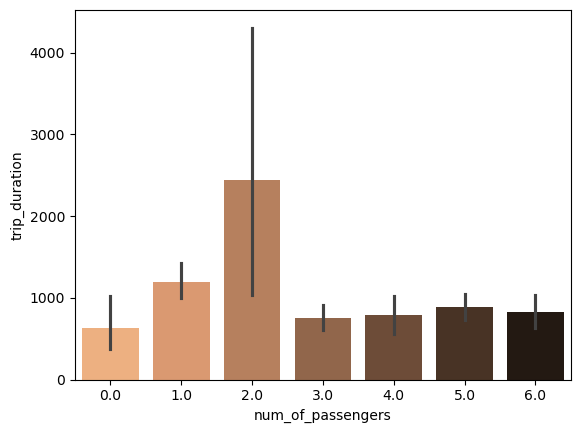

In [48]:
#Converting dataset into barplot
sns.barplot(x="num_of_passengers",y="trip_duration",data=ds,palette="copper_r")

In this plot, the height of each bar corresponds to the average trip duration for a given number of passengers.If you observe that 2.0 passengers have the highest trip duration, it means that trips with exactly 2 passengers, on average, took the longest time compared to trips with other numbers of passengers.

# Scatterplot

<Axes: xlabel='num_of_passengers', ylabel='trip_duration'>

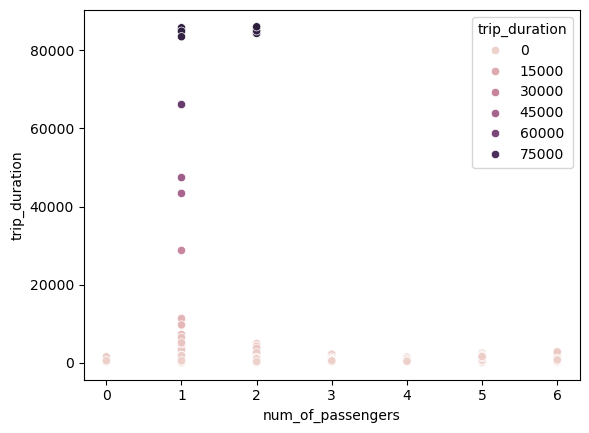

In [51]:
sns.scatterplot(x="num_of_passengers",y="trip_duration",data=ds,hue="trip_duration")

The scatter plot created by sns.scatterplot(x="num_of_passengers", y="trip_duration", data=ds, hue="trip_duration") shows the relationship between the number of passengers and trip duration. The x-axis represents the number of passengers, and the y-axis represents the trip duration. Points are colored based on trip duration, highlighting patterns such as whether longer trips tend to have more passengers or if there are clusters of similar durations.

# Pairplot

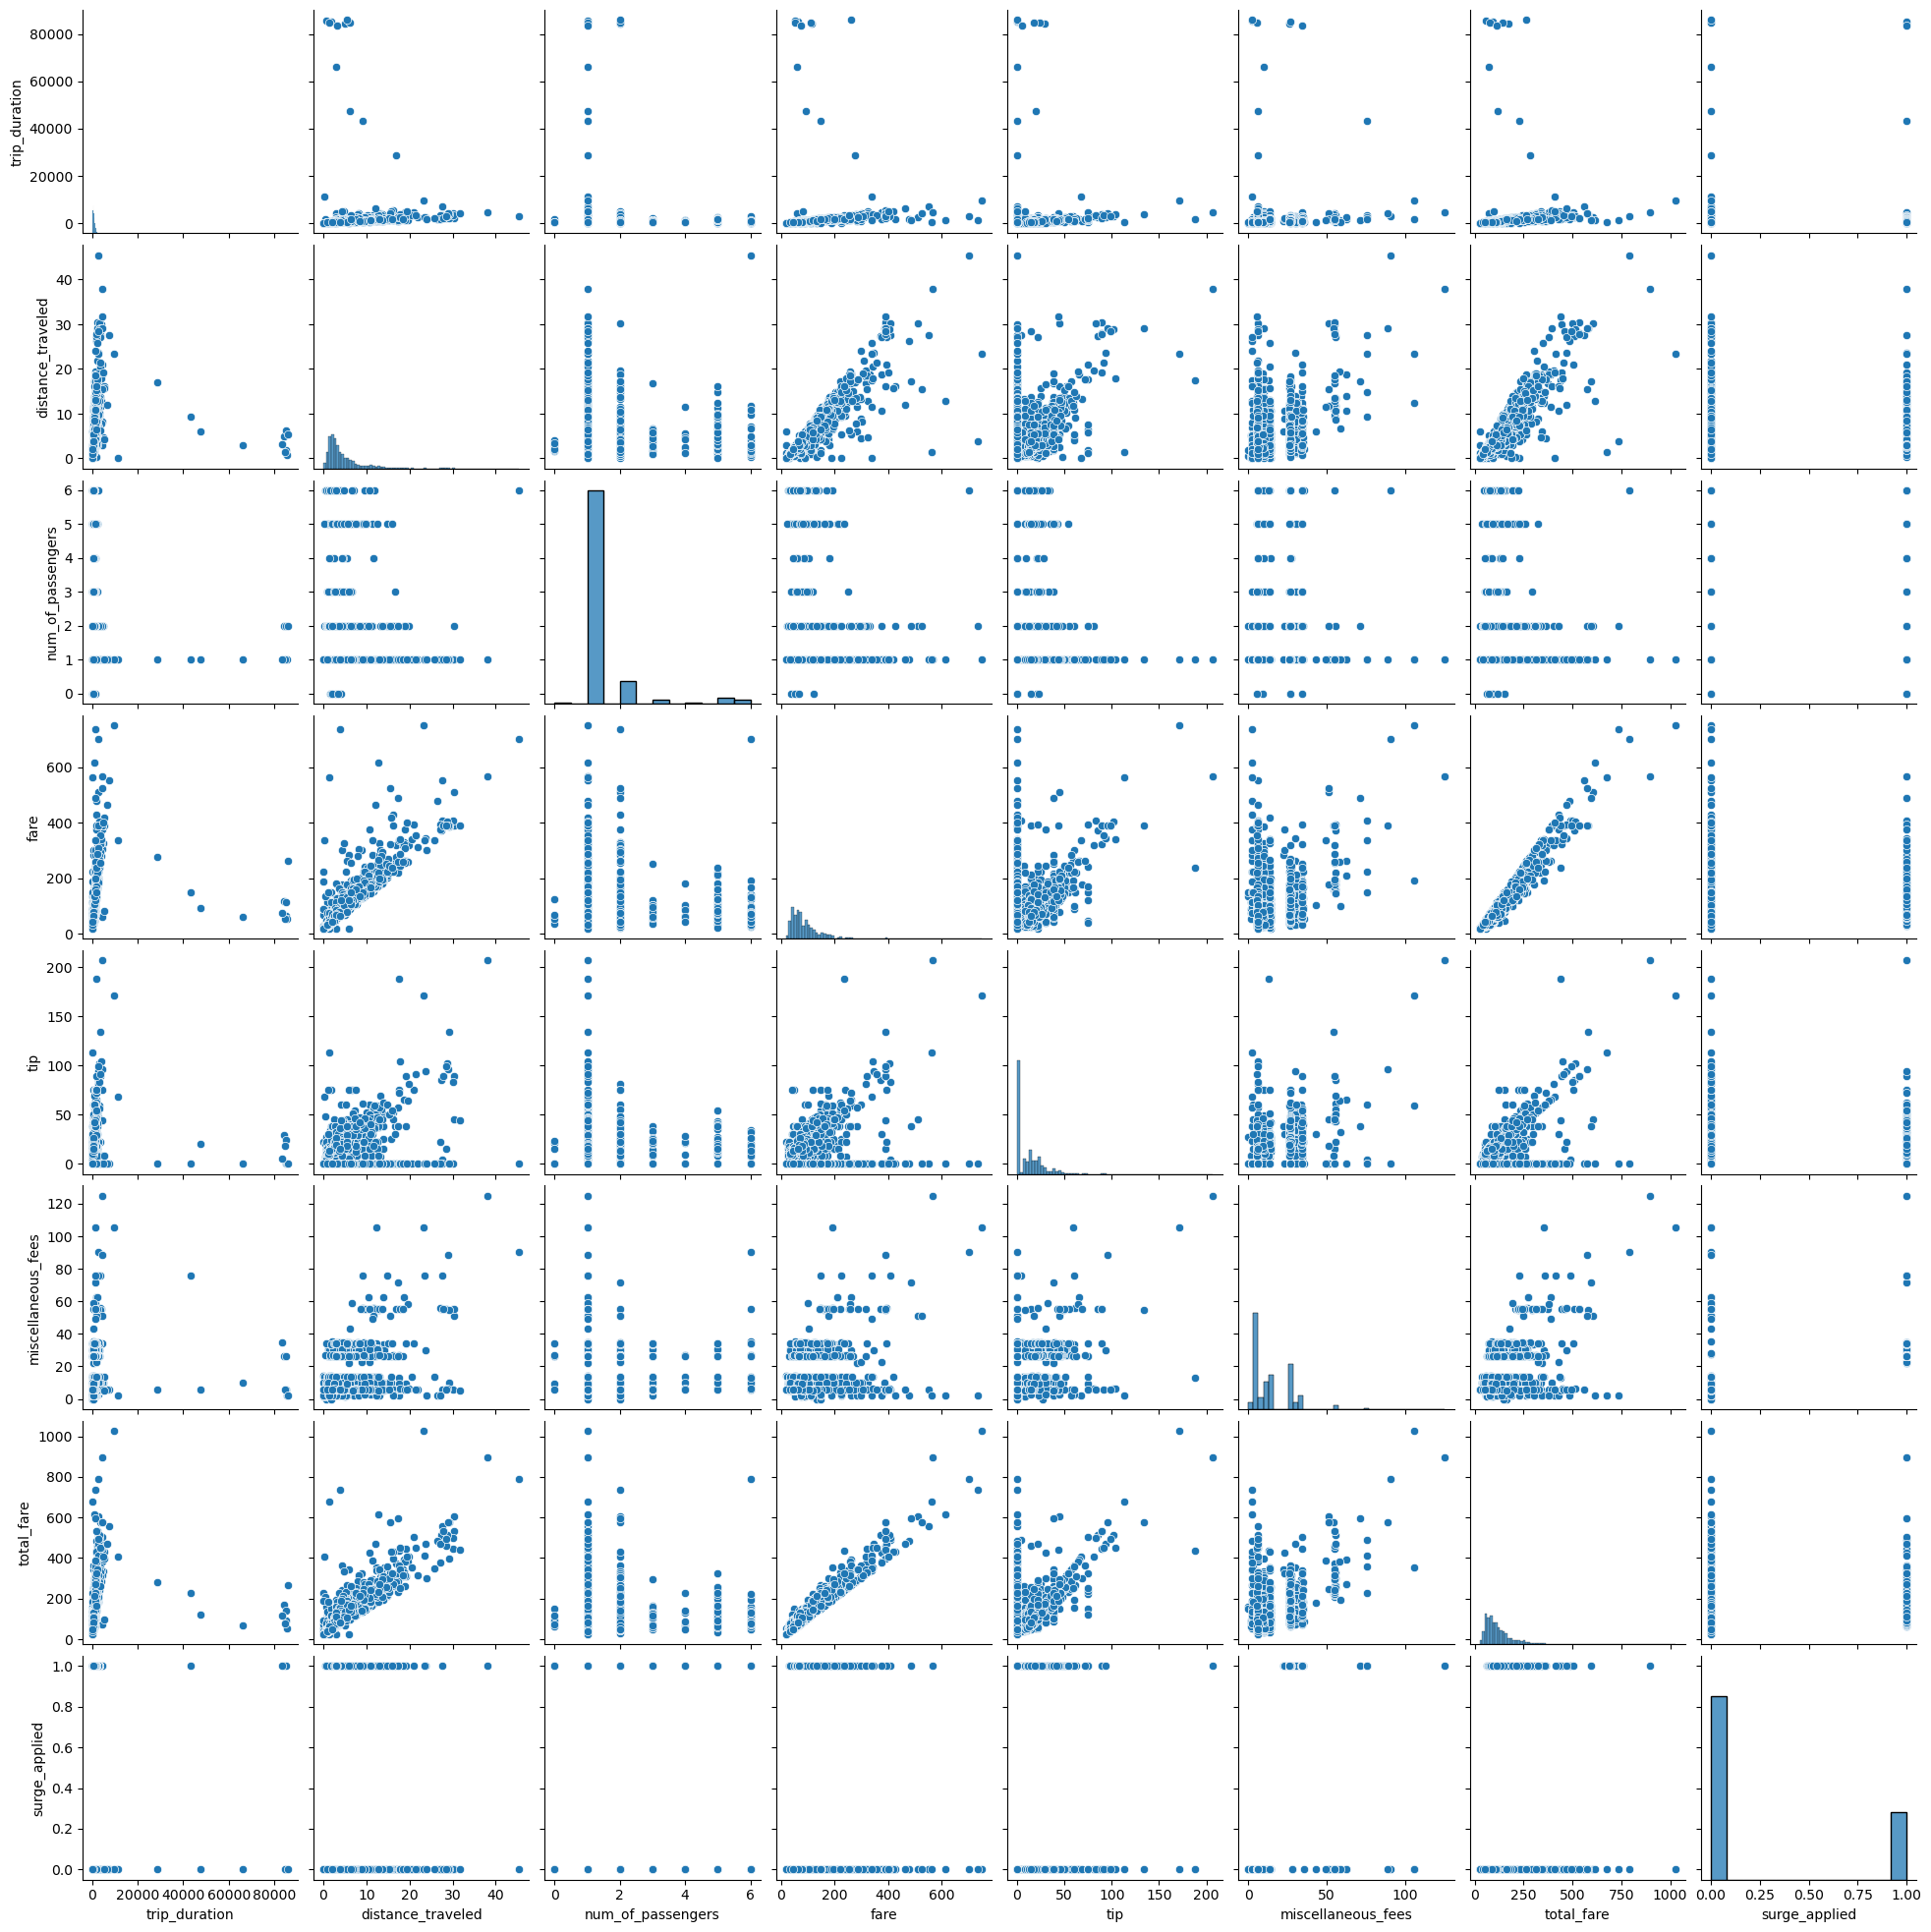

In [55]:
sns.pairplot(ds)

The sns.pairplot(ds) function creates a grid of scatter plots to visualize relationships between all pairs of numerical variables in the dataset ds. It also includes histograms or density plots along the diagonal to show the distribution of each individual variable. 

# Heatmap

<Axes: >

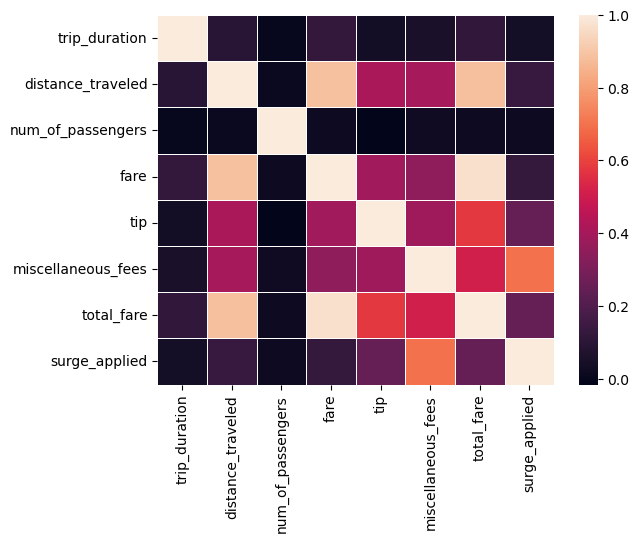

In [58]:
sns.heatmap(ds.corr(),cbar=True,lw=0.5)

The heatmap generated by sns.heatmap(ds.corr(), cbar=True, lw=0.5) visualizes the correlation matrix of the dataset, showing the relationships between different variables. The color bar (cbar=True) indicates the strength of the correlations, while the lw=0.5 adds a small line width between cells for better clarity. This helps identify strong or weak correlations between variables in the dataset.

# Splitting the Datasett

The dataset, "New York City Taxi Fare Predictions," contains data used to predict taxi fares in New York City. In this dataset, surge_applied is treated as the target variable, while other features like trip details, passenger count, and fare information are used as input variables to build a predictive model.

>Training Set: A subset of dataset to train the machine learning model, and we 
already know the output

>Test set: A subset of dataset to test the machine learning model, and by 
using the test set, model predicts the output..

In [63]:
#Feature
x=ds.drop(["surge_applied"],axis=1).values
x

array([[7.4800e+02, 2.7500e+00, 1.0000e+00, ..., 2.4000e+01, 6.3000e+00,
        1.0530e+02],
       [1.1870e+03, 3.4300e+00, 1.0000e+00, ..., 2.4000e+01, 1.3200e+01,
        1.4220e+02],
       [7.3000e+02, 3.1200e+00, 1.0000e+00, ..., 0.0000e+00, 2.6625e+01,
        9.7875e+01],
       ...,
       [1.8260e+03, 6.3900e+00, 1.0000e+00, ..., 0.0000e+00, 1.3500e+01,
        1.6350e+02],
       [5.3300e+02, 3.8500e+00, 1.0000e+00, ..., 1.5000e+01, 6.0000e+00,
        8.4750e+01],
       [3.0200e+02, 2.0000e+00, 2.0000e+00, ..., 0.0000e+00, 6.0000e+00,
        5.1000e+01]])

In [65]:
#Target
y=ds.iloc[:,-1].values
y

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

# Train_Test_Split

In [68]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

The code splits the dataset into training and testing sets using train_test_split. One-third of the data is used for testing (test_size=1/3), and the rest for training. The random_state=0 ensures the split is reproducible.


In [70]:
x_train

array([[4.3500e+02, 1.5800e+00, 1.0000e+00, ..., 1.7000e+01, 3.3700e+01,
        9.9450e+01],
       [7.4100e+02, 4.2300e+00, 1.0000e+00, ..., 1.9000e+01, 1.3700e+01,
        1.1520e+02],
       [2.7800e+02, 1.3500e+00, 1.0000e+00, ..., 0.0000e+00, 6.0000e+00,
        4.7250e+01],
       ...,
       [6.0700e+02, 5.9700e+00, 1.0000e+00, ..., 0.0000e+00, 9.7500e+00,
        1.0725e+02],
       [3.2400e+02, 1.4000e+00, 1.0000e+00, ..., 0.0000e+00, 6.0000e+00,
        4.7250e+01],
       [1.8590e+03, 5.4700e+00, 1.0000e+00, ..., 3.6000e+01, 2.6700e+01,
        2.1645e+02]])

In [71]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [72]:
x_test

array([[8.00000e+02, 2.74000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.00000e+00, 8.10000e+01],
       [9.64000e+02, 4.63000e+00, 1.00000e+00, ..., 0.00000e+00,
        3.41250e+01, 1.27875e+02],
       [5.75000e+02, 6.44000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.00000e+00, 1.07250e+02],
       ...,
       [6.26000e+02, 2.43000e+00, 1.00000e+00, ..., 2.70000e+01,
        2.67750e+01, 1.17525e+02],
       [2.00000e+01, 6.40000e-01, 2.00000e+00, ..., 2.70000e+01,
        0.00000e+00, 1.62000e+02],
       [3.14000e+02, 1.45000e+00, 1.00000e+00, ..., 2.00000e+01,
        3.39250e+01, 9.89250e+01]])

In [77]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

#  1. LOGISTIC REGRESSION

Logistic Regression is a widely used machine learning algorithm for binary classification tasks, where the goal is to predict one of two possible outcomes 

In [81]:
from sklearn.linear_model import LogisticRegression
p=LogisticRegression()
p.fit(x_train,y_train)

C:\Users\reshm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Prediction

In [84]:
# Predict on training data
pred1=p.predict(x_train)
pred1

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [86]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [88]:
# Predict class labels for test data
pred1=p.predict(x_test)
pred1

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [90]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [93]:
# Training Accuracy
print("trainscoring",p.score(x_train,y_train))

trainscoring 0.9392348087021756


After training the Logistic Regression model,The model achieved an accuracy of 93% on the training set

In [96]:
# Test Accuracy
lg=p.score(x_test,y_test)
lg

0.904047976011994

The Logistic Regression model was evaluated on the test data, achieving an accuracy of 90%.

# Confusion Matrix

In [100]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred1)
cm

array([[458,  16],
       [ 48, 145]], dtype=int64)

It shows that 458 true positives, 16 false positives, 48 false negatives, and 145 true negatives. This indicates that the model correctly predicted 458 instances of the positive class and 145 instances of the negative class, while misclassifying 16 positive instances as negative and 48 negative instances as positive.

# 2. DECISION TREE REGRESSION

Decision Tree Regression is a machine learning algorithm used for predicting continuous numerical values. It is an extension of the Decision Tree Classifier but designed for regression tasks.

In [105]:
from sklearn.tree import DecisionTreeClassifier
q=DecisionTreeClassifier()
q.fit(x_train,y_train)

DecisionTreeClassifier()

# Prediction

In [108]:
# Predict on training data
pred2=q.predict(x_train)
pred2

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [110]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [112]:
pred2=q.predict(x_test)
pred2

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [114]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [117]:
# Training Accuracy
print("trainscoring",q.score(x_train,y_train))

trainscoring 1.0


After training the Decision Tree model,The model achieved an accuracy of 1.0 on the training set.An accuracy of 1.0 indicates that the model perfectly predicted all training samples.

In [120]:
# Test Accuracy
dtc=q.score(x_test,y_test)
dtc

0.9970014992503748

The Decison Tree model was evaluated on the test data, achieving an accuracy of 99%

# Confusion Matrix

In [124]:
from sklearn.metrics import confusion_matrix
cm2=confusion_matrix(y_test,pred2)
cm2

array([[473,   1],
       [  1, 192]], dtype=int64)

The model correctly predicted 471 true negatives and 192 true positives.It made 3 false positives and 1 false negative.

# 3. KNN

K-Nearest Neighbors (KNN) Regression is a machine learning algorithm used for predicting continuous numerical values based on the proximity of data points. Unlike other regression algorithms that model relationships between the features and target, KNN makes predictions based on the average of the target values of the nearest neighbors.

In [129]:
from sklearn.neighbors import KNeighborsClassifier  
r= KNeighborsClassifier(n_neighbors=5 )  
r.fit(x_train, y_train)

KNeighborsClassifier()

# Prediction

In [132]:
# Predict on training data
pred3=r.predict(x_train)
pred3

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [133]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [136]:
# Predict class labels for test data
pred3=r.predict(x_test)
pred3

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [138]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [141]:
# Training Accuracy
print("trainscoring",r.score(x_train,y_train))

trainscoring 0.9347336834208552


After training the KNN model,The model achieved an accuracy of 9.3 on the training set.

In [144]:
# Test Accuracy
knn=r.score(x_test,y_test)
knn

0.8575712143928036

The KNN model was evaluated on the test data, achieving an accuracy of 85%

# Confusion Matrix

In [148]:
from sklearn.metrics import confusion_matrix
cm3=confusion_matrix(y_test,pred3)
cm3

array([[431,  43],
       [ 52, 141]], dtype=int64)

The model correctly predicted 431 instances of the True Negatives and 141 instances of the True Positives. However, it misclassified 43 negative instances as False Positives and 52 positive instances as False Negatives. 

# 4. NAIVE BAYES

Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem, which is commonly used for classification tasks but can also be adapted for regression problems in some cases. 

In [153]:
from sklearn.naive_bayes import GaussianNB
s=GaussianNB()
s.fit(x_train,y_train)

GaussianNB()

# Prediction

In [156]:
# Predict on training data
pred4=s.predict(x_train)
pred4

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [158]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [160]:
# Predict class labels for test data
pred4=s.predict(x_test)
pred4

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [162]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [165]:
# Training Accuracy
print("trainscoring",s.score(x_train,y_train))

trainscoring 0.9722430607651913


After training the Naive Bayes model,The model achieved an accuracy of 97% on the training set.

In [168]:
# Test Accuracy
nb=s.score(x_test,y_test)
nb

0.952023988005997

The Naive Bayes model was evaluated on the test data, achieving an accuracy of 95%

# Confusion Matrix

In [172]:
from sklearn.metrics import confusion_matrix
cm4=confusion_matrix(y_test,pred4)
cm4

array([[463,  11],
       [ 21, 172]], dtype=int64)

The model correctly predicted 463 instances of the True Negatives and 172 instances of the True Positives. However, it misclassified 11 negative instances as False Positives and 21 positive instances as False Negatives.

# 5. RANDOM FOREST

Random Forest is a powerful and versatile machine learning algorithm that is widely used for both classification and regression tasks.

In [177]:
from sklearn.ensemble import RandomForestClassifier
t=RandomForestClassifier(random_state=100)
t.fit(x_train,y_train)

RandomForestClassifier(random_state=100)

# Prediction

In [179]:
# Predict on training data
pred5=t.predict(x_train)
pred5

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [180]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [184]:
# Predict class labels for test data
pred5=t.predict(x_test)
pred5

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [186]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [189]:
# Training Accuracy
print("trainscoring",t.score(x_train,y_train))

trainscoring 1.0


After training the Random Forest model,The model achieved an accuracy of 1.0 on the training set.An accuracy of 1.0 indicates that the model perfectly predicted all training sample

In [192]:
# Test Accuracy
rf=t.score(x_test,y_test)
rf

0.9895052473763118

The random forest model was evaluated on the test data, achieving an accuracy of 98%

# Confusion Matrix

In [196]:
from sklearn.metrics import confusion_matrix
cm5=confusion_matrix(y_test,pred5)
cm5

array([[472,   2],
       [  5, 188]], dtype=int64)

The model correctly predicted 472 instances of the True Negatives and 188 instances of the True Positives. However, it misclassified 2 negative instances as False Positives and 5 positive instances as False Negatives.

# 6. SVC

SVC, or Support Vector Classifier, is a machine learning algorithm based on Support Vector Machines (SVM). It is commonly used for classification tasks, where the goal is to separate data points into distinct classes.Works well for both linear and non-linear classification.

In [201]:
from sklearn.svm import SVC
u=SVC(kernel='linear')
u.fit(x_train,y_train)

SVC(kernel='linear')

# Prediction

In [203]:
# Predict on training data
pred6=u.predict(x_train)
pred6

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [204]:
y_train

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [205]:
# Predict class labels for test data
pred6=u.predict(x_test)
pred6

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [206]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

# Finding Accuracy

In [208]:
# Training Accuracy
print("trainscoring",u.score(x_train,y_train))

trainscoring 0.9564891222805701


After training the SVC model,The model achieved an accuracy of 95%

In [210]:
# Test Accuracy
svc=u.score(x_test,y_test)
svc

0.9355322338830585

The SVC model was evaluated on the test data, achieving an accuracy of 93%

# Confusion Matrix

In [213]:
from sklearn.metrics import confusion_matrix
cm6=confusion_matrix(y_test,pred6)
cm6

array([[456,  18],
       [ 25, 168]], dtype=int64)

The model correctly predicted 456 instances of the True Negatives and 168 instances of the True Positives. However, it misclassified 18 negative instances as False Positives and 25 positive instances as False Negatives.

# Dataframe

In [216]:
table=pd.DataFrame({
    "MLModel":["LogisticRegression","SVC","DTC","KNN","NaviveBayes","Random Forest"],
    "Score":[lg,svc,dtc,knn,nb,rf]
})
table

,MLModel,Score
0,LogisticRegression,0.904048
1,SVC,0.935532
2,DTC,0.997001
3,KNN,0.857571
4,NaviveBayes,0.952024
5,Random Forest,0.989505


C:\Users\reshm\AppData\Local\Temp\ipykernel_12168\547557651.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MLModel",y="Score",data=table,palette="copper")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'LogisticRegression'),
  Text(1, 0, 'SVC'),
  Text(2, 0, 'DTC'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'NaviveBayes'),
  Text(5, 0, 'Random Forest')])

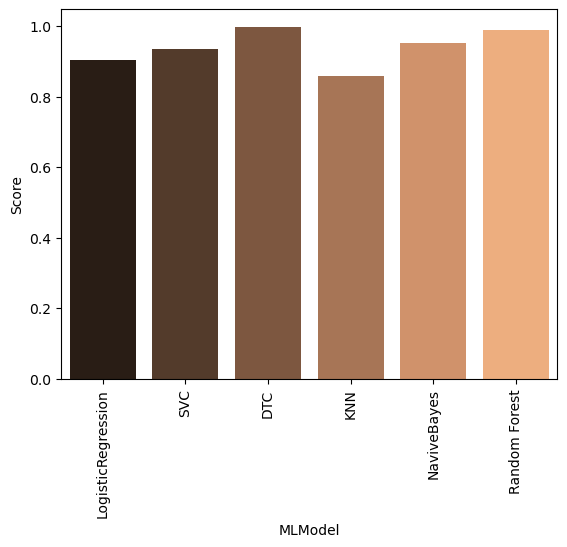

In [217]:
sns.barplot(x="MLModel",y="Score",data=table,palette="copper")
plt.xticks(rotation=90)

The table shows the performance scores of various machine learning models. **Logistic Regression** achieved a score of **0.904**, while the **Support Vector Classifier (SVC)** scored **0.936**. The **Decision Tree Classifier (DTC)** had the highest score of **0.994**, followed by **Naive Bayes** with a score of **0.952**. The **K-Nearest Neighbors (KNN)** model scored the lowest at **0.858**, and **the Random Forest** model scored **0.990**. These scores offer a clear comparison of the models, with Decision Tree Classifier and Random Forest performing the best overall.

# CONCLUSION

This project involved evaluating and comparing various machine learning models for predicting New York City taxi fares. The models tested include Logistic Regression, Support Vector Classifier (SVC), Decision Tree Classifier (DTC), K-Nearest Neighbors (KNN), Naive Bayes, and Random Forest. The results indicate that the **Decision Tree Classifier** achieved the highest performance with a score of **0.994**, closely followed by **Random Forest (0.990)**. **SVC** and **Naive Bayes** also performed well with scores of **0.936** and **0.952**, respectively. However, KNN showed the lowest performance with a score of 0.858. These findings suggest that tree-based models, particularly Decision Tree and Random Forest, are the most effective for this problem, while other models, such as Logistic Regression and SVC, may also offer competitive performance depending on the specific requirements of the task. 